Importing modules

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Defining parameters

In [ ]:


n_users = 35        # secondary users
n_primary = 8       # primary channels
n_channels = 40     # available spectrum bands

noise = 0.1         # noise for SINR

PS_penalty = 75     # penalty for primary-econdary user channel collision
SS_penalty = 25     # penalty for secondary-secondary user channel collision

N=200               # particles
S=n_channels-1      # search space [0, n_channels-1]
D=n_users           # dimensions = number of users
n_iter = 600        # number of updates of positions

a=0.9
b=1.496
b_hat=1.496
c=0.5

beta_start = 1
beta_end = 0.5




Getting SINR from random

In [73]:
# Simulate channel gains randomly (in reality this comes from pathloss model)
# SINR[i][j] = signal quality if user i uses channel j
np.random.seed(67)
channel_gain = np.random.uniform(0.1, 1.0, (n_users, n_channels))     # to get SINR which gets throughput
SINR = channel_gain / noise                                           # simplified, no inter-user interference yet



Setting up Primary Users

In [74]:
# Primary user occupancy: PU[j] = 1 means channel j is occupied by primary user

PU_occupied = np.zeros(n_channels, dtype=int)
PU_occupied[np.random.choice(n_channels, n_primary, replace=False)] = 1

Fitness function which gets the throughput using SINR and adds penalty

In [75]:
def fitness(x, PS_penalty=PS_penalty, SS_penalty=SS_penalty):
    channels = np.clip(np.round(x).astype(int), 0, n_channels - 1)
    pu_mask = PU_occupied[channels]                          # 1 where PU is present
    sinr_vals = SINR[np.arange(n_users), channels]          # SINR for each user's channel
    
    throughput = np.sum(np.log2(1 + sinr_vals) * (1 - pu_mask))
    ps_penalty = np.sum(pu_mask) * PS_penalty
    
    counts = np.bincount(channels, minlength=n_channels)
    ss_pen = np.sum(np.maximum(counts - 1, 0)) * SS_penalty
    
    return -throughput + ps_penalty + ss_pen

PSO algorithm

In [76]:
def dpso(f, D, N, S, n_iter, a, b, b_hat, c, see):
    np.random.seed(see)
    x = np.random.uniform(0, S, size=(N, D))                 # setting up the initial positions of the N number of particles
    v = np.random.normal(size=(N, D))                        # setting up the initial velocities
    p = x.copy()                                             # best particle position
    fp = np.array([f(p[i]) for i in range(N)])               # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                          # global best position
    fp_hat = f(p_hat)                                        # throughput of global best position
    fp_hat_his = []

    for i in range (n_iter):
        fp_hat_his.append(float(fp_hat))
        #if i%(n_iter//10)== 0:                               # to show progress
            #print(f"progress {(i/n_iter)*100:.0f}%")
            #pass
            

        r,r_hat = np.random.uniform(0, 1, (2,N, D))          # setting up random parameters

        v = a*v + b*r*(p-x) + b_hat*r_hat*(p_hat-x)          # updating velocities as vector sum of the directions of initial velocity, local minima, local maxima
        x = x + c*v                                          # updating position according to velocities
        x = np.clip(x, 0, S)                                 # to limit the range within the subspace

        for n in range(N):                                   # calculation for each particle

            xn = x[n]                                        # getting position of that particle           
            fxn = f(xn)                                      # current throughput of that particle
            fpn = fp[n]                                      # best throughput of that particle

            if fxn < fpn:                                    # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                             # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    # print("progress 100%")
    return p_hat,fp_hat_his                                  # "coordinates", ie channel allocation of global best throughput

       



Calling PSO 

In [ ]:
a_values = [0.6, 0.7, 0.729, 0.8, 0.9]
b_values = [1.0, 1.2, 1.496, 1.7, 2.0]   # b_hat kept equal to b
c_values = [0.05, 0.1, 0.2, 0.5, 1.0]
n_seeds  = 25

# shape: (seeds, a, b, c)
results = np.full((n_seeds, len(a_values), len(b_values), len(c_values)), np.nan)

for s in range(n_seeds):
    print(f"seed {s}")
    for ai, a_val in enumerate(a_values):
        print("a ", a_val)
        for bi, b_val in enumerate(b_values):
            
            for ci, c_val in enumerate(c_values):
                
                result, _ = dpso(fitness, D, N, S, n_iter, a_val, b_val, b_val, c_val, s)
                best = np.clip(np.round(result).astype(int), 0, n_channels - 1)
                throughput = sum(
                    np.log2(1 + SINR[user, best[user]])
                    for user in range(n_users)
                    if not PU_occupied[best[user]]
                )
                results[s, ai, bi, ci] = throughput



# --- analysis ---
avg = np.mean(results, axis=0)   # shape: (a, b, c)

best_idx = np.unravel_index(np.argmax(avg), avg.shape)
print(f"\nBest combination:")
print(f"  a     = {a_values[best_idx[0]]}")
print(f"  b     = {b_values[best_idx[1]]}")
print(f"  b_hat = {b_values[best_idx[1]]}")
print(f"  c     = {c_values[best_idx[2]]}")
print(f"  avg throughput = {avg[best_idx]:.3f}")


seed 0
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 1
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 2
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 3
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 4
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 5
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 6
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 7
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 8
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 9
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 10
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 11
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 12
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 13
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 14
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 15
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 16
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 17
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 18
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 19
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 20
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 21
a  0.6
a  0.7
a  0.729
a  0.8
a  0.9
seed 22
a  0.6
a  0.

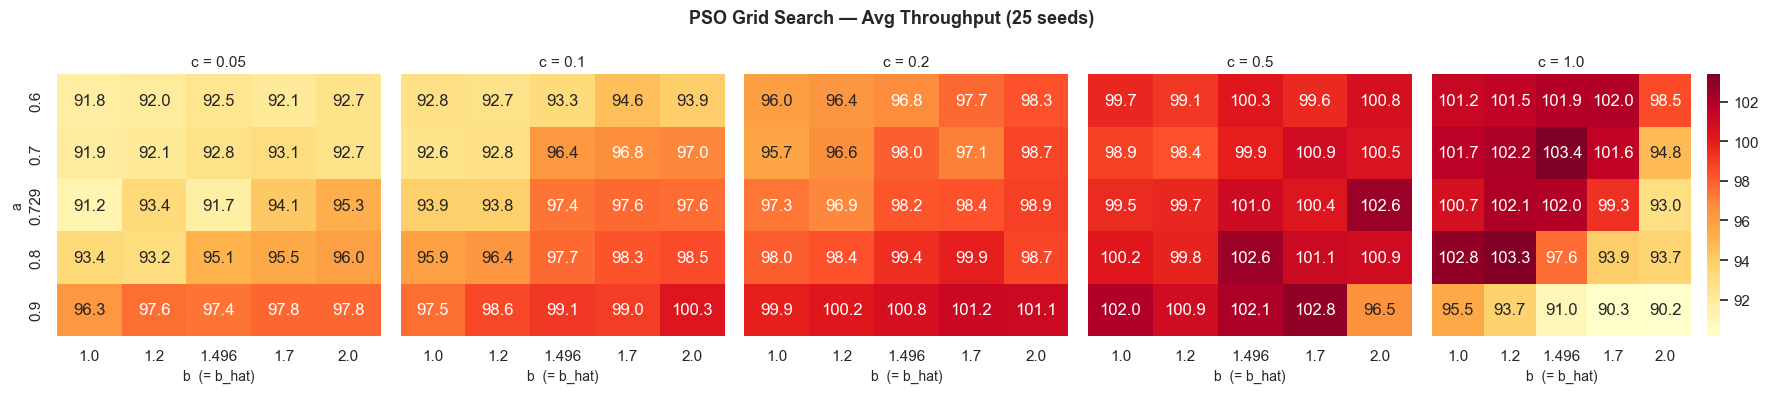

In [86]:

# --- heatmaps: one panel per c value ---
sns.set_theme(style="white")

vmin, vmax = avg.min(), avg.max()
fig, axes = plt.subplots(1, len(c_values), figsize=(18, 4), sharey=True)

for ci, c_val in enumerate(c_values):
    sns.heatmap(
        avg[:, :, ci],
        ax=axes[ci],
        xticklabels=[f"{b}" for b in b_values],
        yticklabels=[f"{a}" for a in a_values],
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        vmin=vmin, vmax=vmax,
        cbar=(ci == len(c_values) - 1)
    )
    axes[ci].set_title(f"c = {c_val}", fontsize=11)
    axes[ci].set_xlabel("b  (= b_hat)", fontsize=10)
    if ci == 0:
        axes[ci].set_ylabel("a", fontsize=10)

fig.suptitle("PSO Grid Search — Avg Throughput (25 seeds)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(
    Path.home() / "OneDrive" / "Desktop" / "grid_search_heatmap.png",
    dpi=400,
    bbox_inches="tight"
)
plt.show()


In [79]:
np.save(Path.home() / "OneDrive" / "Desktop" / "grid_results.npy", results)
np.save(Path.home() / "OneDrive" / "Desktop" /"grid_avg.npy", avg)
np.save(Path.home() / "OneDrive" / "Desktop" /"a_values.npy", np.array(a_values))
np.save(Path.home() / "OneDrive" / "Desktop" /"b_values.npy", np.array(b_values))
np.save(Path.home() / "OneDrive" / "Desktop" /"c_values.npy", np.array(c_values))

In [87]:
c_idx = c_values.index(0.5)

std_c05 = np.std(results[:, :, :, c_idx], axis=0)   # std across seeds

# print mean ± std for the top few cells
avg_c05 = avg[:, :, c_idx]
for ai in range(len(a_values)):
    for bi in range(len(b_values)):
        print(f"a={a_values[ai]}, b={b_values[bi]}: {avg_c05[ai,bi]:.1f} ± {std_c05[ai,bi]:.1f}")

a=0.6, b=1.0: 99.7 ± 2.6
a=0.6, b=1.2: 99.1 ± 3.1
a=0.6, b=1.496: 100.3 ± 3.3
a=0.6, b=1.7: 99.6 ± 3.4
a=0.6, b=2.0: 100.8 ± 3.4
a=0.7, b=1.0: 98.9 ± 2.9
a=0.7, b=1.2: 98.4 ± 2.8
a=0.7, b=1.496: 99.9 ± 3.3
a=0.7, b=1.7: 100.9 ± 2.4
a=0.7, b=2.0: 100.5 ± 3.4
a=0.729, b=1.0: 99.5 ± 3.2
a=0.729, b=1.2: 99.7 ± 3.6
a=0.729, b=1.496: 101.0 ± 3.1
a=0.729, b=1.7: 100.4 ± 3.6
a=0.729, b=2.0: 102.6 ± 3.4
a=0.8, b=1.0: 100.2 ± 3.2
a=0.8, b=1.2: 99.8 ± 3.1
a=0.8, b=1.496: 102.6 ± 2.7
a=0.8, b=1.7: 101.1 ± 4.3
a=0.8, b=2.0: 100.9 ± 2.7
a=0.9, b=1.0: 102.0 ± 3.8
a=0.9, b=1.2: 100.9 ± 3.6
a=0.9, b=1.496: 102.1 ± 2.5
a=0.9, b=1.7: 102.8 ± 3.4
a=0.9, b=2.0: 96.5 ± 3.2


In [80]:
'''
n_seeds = 100
b_values = np.arange(0.0, 1.1, 0.1)
results = np.empty((n_seeds, len(b_values)))

for s in range(n_seeds):
    print("seed", s)
    for bi, b in enumerate(b_values):
        result, history = dpso(fitness, D, N, S, n_iter, a, b, b_hat, c,s)
        C_best_assignment = np.clip(np.round(result).astype(int), 0, n_channels-1)
        C_throughput = 0
        for user in range(n_users):
            ch = C_best_assignment[user]
            if not PU_occupied[ch]:
                C_throughput += np.log2(1 + SINR[user, ch])
        results[s, bi] = C_throughput   
avg_throughput = np.mean(results, axis=0)


'''


'\nn_seeds = 100\nb_values = np.arange(0.0, 1.1, 0.1)\nresults = np.empty((n_seeds, len(b_values)))\n\nfor s in range(n_seeds):\n    print("seed", s)\n    for bi, b in enumerate(b_values):\n        result, history = dpso(fitness, D, N, S, n_iter, a, b, b_hat, c,s)\n        C_best_assignment = np.clip(np.round(result).astype(int), 0, n_channels-1)\n        C_throughput = 0\n        for user in range(n_users):\n            ch = C_best_assignment[user]\n            if not PU_occupied[ch]:\n                C_throughput += np.log2(1 + SINR[user, ch])\n        results[s, bi] = C_throughput   \navg_throughput = np.mean(results, axis=0)\n\n\n'

In [81]:
'''
sns.set_theme(style="darkgrid")

# actual n_iter values used: SS+1 for SS in range(0, n_parameter, 10)
iter_values = list(a_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iter_values, avg_throughput, color="#2196F3", linewidth=2)

ax.set_xlabel("Values of parameter \"b\"", fontsize=11)
ax.set_ylabel("Avg Throughput", fontsize=11)
ax.set_title("PSO — Values of parameter \"b\" vs Throughput\n(averaged over 100 seeds)",fontsize=12, fontweight="bold")

ymin = np.floor(min(avg_throughput))
ymax = np.ceil(max(avg_throughput))
ax.set_yticks(np.arange(ymin, ymax + 1, 1))

plt.tight_layout()
plt.savefig(
    Path.home() / "OneDrive" / "Desktop" / "pso_b_sweep.png",
    dpi=400,
    bbox_inches="tight"
)
plt.show()
'''

'\nsns.set_theme(style="darkgrid")\n\n# actual n_iter values used: SS+1 for SS in range(0, n_parameter, 10)\niter_values = list(a_values)\n\nfig, ax = plt.subplots(figsize=(8, 5))\nax.plot(iter_values, avg_throughput, color="#2196F3", linewidth=2)\n\nax.set_xlabel("Values of parameter "b"", fontsize=11)\nax.set_ylabel("Avg Throughput", fontsize=11)\nax.set_title("PSO — Values of parameter "b" vs Throughput\n(averaged over 100 seeds)",fontsize=12, fontweight="bold")\n\nymin = np.floor(min(avg_throughput))\nymax = np.ceil(max(avg_throughput))\nax.set_yticks(np.arange(ymin, ymax + 1, 1))\n\nplt.tight_layout()\nplt.savefig(\n    Path.home() / "OneDrive" / "Desktop" / "pso_b_sweep.png",\n    dpi=400,\n    bbox_inches="tight"\n)\nplt.show()\n'

In [82]:
#np.save(Path.home() / "OneDrive" / "Desktop" / "grid_results.npy", results)
#np.save(Path.home() / "OneDrive" / "Desktop" / "avg_throughput_b.npy", avg_throughput)


QPSO algorithm

In [83]:
def dqpso(f, D, N, S, n_iter, beta_start, beta_end):

    x = np.random.uniform(0, S, size=(N, D))                            # setting up the initial positions of the N number of particles
    p = x.copy()                                                        # best particle position
    fp = np.array([f(p[i]) for i in range(N)])                          # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                                     # global best position
    fp_hat = f(p_hat)                                                   # throughput of global best position


    for i in range(n_iter):

        if i%(n_iter//10)== 0:                                          # to show progress
            print(f"progress {(i/n_iter)*100:.0f}%")
        
        
        beta = beta_start - (beta_start - beta_end) * i / n_iter        # Beta decreases linearly from beta_start to beta_end

        mbest = np.mean(p, axis=0)                                      # Mean best position ie average of all personal bests

        phi = np.random.uniform(0,1, (N,D))                             
        p_local = phi * p + (1 - phi) * p_hat                           # local attractor for each particle (works like velocity or inertia)

        u = np.random.uniform(1e-12, 1, (N,D))                           
        sign = 2 * np.random.randint(0, 2, size=(N,D)) - 1
        x = p_local + sign * beta * np.abs(mbest - x) * np.log(1/u)     # calculates the next value of x
        x = np.clip(x, 0, S)                                            # to limit the range within the subspace


        for n in range(N):                                              # calculation for each particle

            xn = x[n]                                                   # getting position of that particle           
            fxn = f(xn)                                                 # current throughput of that particle
            fpn = fp[n]                                                 # best throughput of that particle

            if fxn < fpn:                                               # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                                        # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    print("progress 100%")
    return p_hat                                                        # "coordinates", ie channel allocation of global best throughput

            

    

Calling QPSO

In [84]:
"""
result_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)

Q_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)

Q_throughput = 0
for user in range(n_users):
    ch = Q_best_assignment[user]
    if not PU_occupied[ch]:
        Q_throughput += np.log2(1 + SINR[user, ch])
"""



'\nresult_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)\n\nQ_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)\n\nQ_throughput = 0\nfor user in range(n_users):\n    ch = Q_best_assignment[user]\n    if not PU_occupied[ch]:\n        Q_throughput += np.log2(1 + SINR[user, ch])\n'

In [85]:
'''
print("Classical Particle Swarm Optimization\n")
print("Channel assignment:", C_best_assignment)
print("Throughput:", C_throughput)

print("\n\nQuantum Particle Swarm Optimization \n")
print("Channel assignment:", Q_best_assignment)
print("Throughput:", Q_throughput)
'''

'\nprint("Classical Particle Swarm Optimization\n")\nprint("Channel assignment:", C_best_assignment)\nprint("Throughput:", C_throughput)\n\nprint("\n\nQuantum Particle Swarm Optimization \n")\nprint("Channel assignment:", Q_best_assignment)\nprint("Throughput:", Q_throughput)\n'